In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [5]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

         date  open   high   low  close  volume
0  2000-08-30  4.65  4.815  4.63  4.805   34954
1  2000-08-31  4.82  4.870  4.74  4.780   25787
2  2000-09-01  4.75  4.860  4.75  4.835     113
3  2000-09-05  4.85  4.975  4.84  4.960   26096
4  2000-09-06  4.99  5.110  4.96  5.065   32764


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [7]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

# Tạo tập dữ liệu theo cửa sổ thời gian
window_size = 5


In [8]:
df_scaled.head(6)

,open,high,low,close,volume
date,,,,,
2000-08-30,0.233909,0.228523,0.238319,0.239134,0.076120
2000-08-31,0.246301,0.232393,0.246516,0.237334,0.056157
2000-09-01,0.241198,0.231689,0.247261,0.241292,0.000246
2000-09-05,0.248487,0.239780,0.253968,0.250288,0.056830
2000-09-06,0.258692,0.249279,0.262911,0.257844,0.071351
2000-09-07,0.256506,0.244354,0.257694,0.253022,0.082971


In [9]:
def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i + window_size].values)  # Lấy 5 ngày trước
        y.append(data.iloc[i + window_size]['close'])  # Dự đoán giá đóng cửa ngày tiếp theo
    return np.array(X), np.array(y)

In [10]:
X, y = create_multivariate_sequences(df_scaled, window_size)


In [11]:
from sklearn.model_selection import train_test_split


In [12]:
# Chia tập train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.2, shuffle=False)

print("Shape of datasets:")
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

Shape of datasets:
(4780, 5, 5) (4780,) (956, 5, 5) (956,) (239, 5, 5) (239,)


In [13]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer


In [14]:
def build_lstm_model():
    model = Sequential()
    model.add(InputLayer((window_size, X.shape[2])))  # Input có 5 time steps, số features theo dataset
    model.add(LSTM(128, return_sequences=True))  # LSTM thứ nhất với 128 neurons
    model.add(Dropout(0.2))  # Dropout giúp tránh overfitting
    model.add(LSTM(64))  # LSTM thứ hai với 64 neurons
    model.add(Dense(32, activation='relu'))  # Dense ẩn
    model.add(Dense(1, activation='linear'))  # Output dự đoán giá close
    return model

model = build_lstm_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 128)         │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import ModelCheckpoint


In [ ]:
# Callback lưu model tốt nhất
cp = ModelCheckpoint('best_lstm_model.keras', save_best_only=True, monitor='val_loss')

# Compile model
model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.05), metrics=[RootMeanSquaredError()])

# Train model
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val), 
                    epochs=150, #0.0001
                    batch_size=32, 
                    callbacks=[cp])


Epoch 1/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0016 - root_mean_squared_error: 0.0385 - val_loss: 7.7645e-04 - val_root_mean_squared_error: 0.0279
Epoch 2/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.1473e-04 - root_mean_squared_error: 0.0177 - val_loss: 4.3885e-04 - val_root_mean_squared_error: 0.0209
Epoch 3/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.4850e-04 - root_mean_squared_error: 0.0233 - val_loss: 6.3667e-04 - val_root_mean_squared_error: 0.0252
Epoch 4/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.5985e-04 - root_mean_squared_error: 0.0235 - val_loss: 9.1704e-04 - val_root_mean_squared_error: 0.0303
Epoch 5/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.9869e-04 - root_mean_squared_error: 0.0244 - val_loss: 5.8291e-04 - val_root_mean_squared_error: 0.0241
Epoch 6/150
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.4045e-04 - root_mean_squared_error: 0.0271 - val_loss: 5.0279e-04 - val_root_mean_squared_error: 0.0

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Tính các độ lỗi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# In kết quả
print(f"📌 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📌 Mean Squared Error (MSE): {mse:.4f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 R-squared (R²): {r2:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
📌 Mean Absolute Error (MAE): 0.0111
📌 Mean Squared Error (MSE): 0.0002
📌 Root Mean Squared Error (RMSE): 0.0132
📌 R-squared (R²): 0.8655


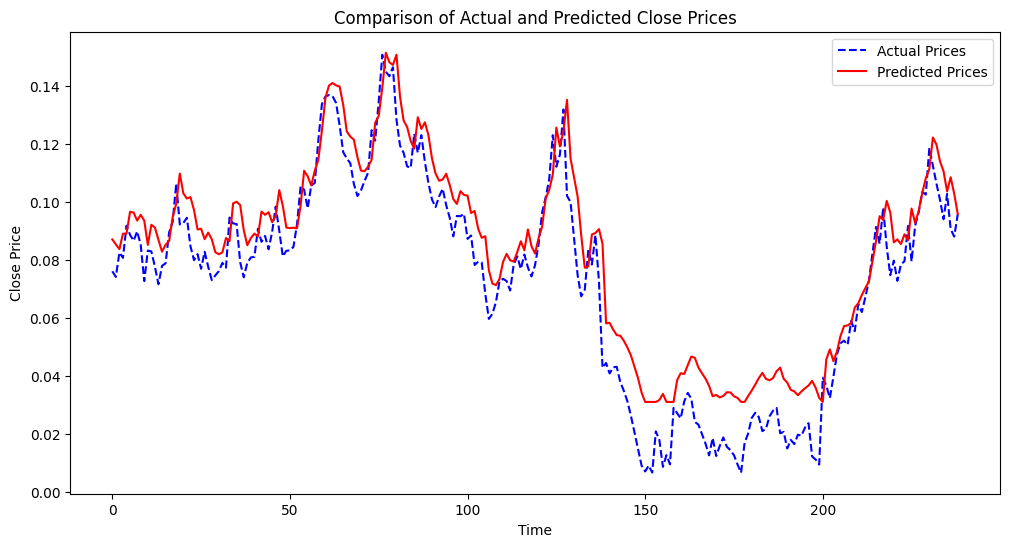

In [19]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ so sánh giá trị thực tế và dự đoán
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual Prices", color='blue', linestyle='dashed')
plt.plot(y_pred, label="Predicted Prices", color='red')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Comparison of Actual and Predicted Close Prices")
plt.legend()
plt.show()
